# SRP04b — Held-out distribution-shift feasibility audit

**Author:** Ildefons Magrans de Abril  
**Affiliation:** Universitat Politècnica de Catalunya - BarcelonaTech (UPC)

**Purpose.** Quantify structural opportunity under held-out shifts using matched temperature–leak candidate sets, and compare deployable pre-deployment choices with retrospective target-label upper bounds.

**Provenance.** Publication copy of the original executed SRP04b analysis notebook. Scientific code and frozen settings are preserved; the title, terminology note, and repository output path are cleaned for release.

The manuscript denotes the historically screened multidimensional subset by $\Theta_{\mathrm{cert}}$ to keep it distinct from the one-dimensional validation-safe temperature region $\mathcal{T}_{\mathrm{safe}}$. Some internal variable names in this preserved notebook predate that terminology change.

**Execution note.** Embedded outputs are retained from the original full execution. Any absolute paths printed inside those historical outputs refer to the original workstation. Re-running this publication copy writes to the repository `results/reproduced/` directory.

In [1]:

# ============================================================
# Imports and configuration
# ============================================================
import os
import time
import warnings
from pathlib import Path
from typing import Dict, List, Tuple

os.environ.setdefault("OMP_NUM_THREADS", "1")
os.environ.setdefault("OPENBLAS_NUM_THREADS", "1")
os.environ.setdefault("MKL_NUM_THREADS", "1")
os.environ.setdefault("NUMEXPR_NUM_THREADS", "1")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.stats import spearmanr
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

GLOBAL_SEED = 20260723
OUTDIR = (Path("../results/reproduced/SRP04b") if Path.cwd().name == "notebooks" else Path("results/reproduced/SRP04b"))
OUTDIR.mkdir(exist_ok=True)

# Set SRP04B_SMOKE=1 for a rapid Restart & Run All verification.
SMOKE_TEST = os.environ.get("SRP04B_SMOKE", "0") == "1"

if SMOKE_TEST:
    TASKS = ["narma10"]
    RESERVOIR_SEEDS = [0]
    N = 14
    AXIS_SIZE = 3
    TRAIN_LENGTH = 180
    VALID_LENGTH = 90
    WASHOUT = 20
    CONTEXT_LENGTH = 28
    FUTURE_LENGTH = 36
    N_META_EPISODES = 2
    N_TEST_EPISODES = 1
    RIDGE_GRID = np.array([1e-3, 1e-2])
    EXTRA_TREES = 25
    HQ_MIN = 4
    SPARSE_SUPPORT = 2
else:
    TASKS = ["narma10", "mackey_glass", "lorenz_x"]
    RESERVOIR_SEEDS = [0, 1, 2]
    N = 45
    AXIS_SIZE = 11
    TRAIN_LENGTH = 1100
    VALID_LENGTH = 400
    WASHOUT = 80
    CONTEXT_LENGTH = 180
    FUTURE_LENGTH = 180
    N_META_EPISODES = 6
    N_TEST_EPISODES = 4
    RIDGE_GRID = np.array([1e-6, 1e-5, 1e-4, 1e-3, 1e-2])
    EXTRA_TREES = 250
    HQ_MIN = 25
    SPARSE_SUPPORT = 5

TAU_VALUES = np.exp(
    np.linspace(np.log(0.08), np.log(3.50), AXIS_SIZE)
)
ALPHA_VALUES = np.linspace(0.10, 1.00, AXIS_SIZE)

INPUT_SCALE = 0.8
FIXED_BULK_SCALE = 1.0
NOISE_RHO = 0.70
GAIN_RHO = 0.985
OFFSET_RHO = 0.995
HQ_REL_TOL = 0.15

META_CONDITIONS = [
    ("clean", 0.0),
    ("additive_ar1", 0.35),
    ("additive_ar1", 0.75),
    ("gain_drift", 0.50),
    ("gain_drift", 1.00),
]
TEST_CONDITIONS = [
    ("additive_ar1", 1.10),
    ("offset_drift", 0.60),
    ("offset_drift", 1.00),
    ("block_missing", 0.50),
    ("block_missing", 1.00),
]
if SMOKE_TEST:
    META_CONDITIONS = [
        ("clean", 0.0),
        ("additive_ar1", 0.50),
        ("gain_drift", 0.75),
    ]
    TEST_CONDITIONS = [
        ("additive_ar1", 1.00),
        ("offset_drift", 0.75),
    ]

PROXY_TEMPERATURE = 0.15
META_SHRINKAGE_GRID = np.array([0.0, 0.25, 0.50, 0.75, 1.0])
META_RIDGE_ALPHAS = np.array(
    [1e-3, 1e-2, 1e-1, 1.0, 10.0]
) if not SMOKE_TEST else np.array([1e-2, 1.0])

MIN_ORACLE_RELATIVE_GAIN = 0.05
MIN_CAPTURE_FRACTION = 0.20
MIN_ROBUST_RELATIVE_GAIN = 0.02
MAX_NEGATIVE_TRANSFER = 0.02
MIN_TASK_FRACTION = 2.0 / 3.0

print("SRP04b — final corrected journal feasibility audit")
print("smoke test:", SMOKE_TEST)
print("tasks:", TASKS)
print("reservoir seeds:", RESERVOIR_SEEDS)
print("grid:", AXIS_SIZE, "x", AXIS_SIZE)
print("meta conditions:", META_CONDITIONS)
print("test conditions:", TEST_CONDITIONS)
print("output:", OUTDIR.resolve())


# Final corrected decision thresholds.
ORACLE_VALIDITY_TOL = 1e-9
MAX_PRICE_OF_SAFETY_RELATIVE = 0.05
MIN_POLICY_WIN_FRACTION = 0.55


SRP04b — final corrected journal feasibility audit
smoke test: False
tasks: ['narma10', 'mackey_glass', 'lorenz_x']
reservoir seeds: [0, 1, 2]
grid: 11 x 11
meta conditions: [('clean', 0.0), ('additive_ar1', 0.35), ('additive_ar1', 0.75), ('gain_drift', 0.5), ('gain_drift', 1.0)]
test conditions: [('additive_ar1', 1.1), ('offset_drift', 0.6), ('offset_drift', 1.0), ('block_missing', 0.5), ('block_missing', 1.0)]
output: /home/ildefons/agentecon/SRP04b_outputs


In [2]:

# ============================================================
# Numerical utilities
# ============================================================
def stable_softmax(x: np.ndarray, axis: int = -1) -> np.ndarray:
    z = np.asarray(x, dtype=float)
    z = z - np.max(z, axis=axis, keepdims=True)
    ez = np.exp(z)
    return ez / (
        np.sum(ez, axis=axis, keepdims=True) + 1e-12
    )


def normalize_series(x: np.ndarray) -> np.ndarray:
    x = np.asarray(x, dtype=float)
    return (
        x - np.mean(x)
    ) / (np.std(x) + 1e-12)


def regression_metrics(
    y: np.ndarray,
    pred: np.ndarray,
) -> Dict[str, float]:
    y = np.asarray(y, dtype=float).reshape(-1)
    pred = np.asarray(pred, dtype=float).reshape(-1)
    mse = float(np.mean((pred - y) ** 2))
    return {
        "mse": mse,
        "nrmse": float(
            np.sqrt(mse) / (np.std(y) + 1e-12)
        ),
    }


def normalize_weights(w: np.ndarray) -> np.ndarray:
    w = np.maximum(
        np.asarray(w, dtype=float).reshape(-1),
        0.0,
    )
    total = float(np.sum(w))
    if (
        not np.isfinite(total)
        or total <= 1e-14
    ):
        return np.full(len(w), 1.0 / len(w))
    return w / total


def make_ar1_unit(
    T: int,
    rho: float,
    rng: np.random.Generator,
) -> np.ndarray:
    eps = rng.normal(size=T)
    x = np.zeros(T, dtype=float)
    innovation = np.sqrt(
        max(1.0 - rho ** 2, 1e-12)
    )
    for t in range(1, T):
        x[t] = (
            rho * x[t - 1]
            + innovation * eps[t]
        )
    return normalize_series(x)


def structural_coordinates(coord_df: pd.DataFrame):
    x = (
        np.log(coord_df["tau"].to_numpy(float))
        - np.log(TAU_VALUES[0])
    ) / (
        np.log(TAU_VALUES[-1])
        - np.log(TAU_VALUES[0])
        + 1e-12
    )
    y = (
        coord_df["alpha"].to_numpy(float)
        - ALPHA_VALUES[0]
    ) / (
        ALPHA_VALUES[-1]
        - ALPHA_VALUES[0]
        + 1e-12
    )
    return np.stack([x, y], axis=1)


def sanitize_matrix(
    df: pd.DataFrame,
    features: List[str],
):
    X = df[features].to_numpy(
        dtype=float, copy=True
    )
    X[~np.isfinite(X)] = np.nan
    medians = np.nanmedian(X, axis=0)
    medians[~np.isfinite(medians)] = 0.0
    missing = np.where(np.isnan(X))
    X[missing] = medians[missing[1]]
    return X


In [3]:

# ============================================================
# Forecasting task generators
# ============================================================
def make_narma10(
    T: int,
    rng: np.random.Generator,
):
    order = 10
    warm = 180
    length = T + warm + order + 4

    for _ in range(50):
        u = rng.uniform(0.0, 0.5, size=length)
        y = np.zeros(length)
        stable = True

        with np.errstate(over="ignore", invalid="ignore"):
            for t in range(order, length - 1):
                y[t + 1] = (
                    0.3 * y[t]
                    + 0.05
                    * y[t]
                    * np.sum(
                        y[t - order + 1:t + 1]
                    )
                    + 1.5
                    * u[t - order + 1]
                    * u[t]
                    + 0.1
                )
                if (
                    not np.isfinite(y[t + 1])
                    or abs(y[t + 1]) > 100.0
                ):
                    stable = False
                    break

        start = warm + order
        target = y[start:start + T]
        if stable and np.std(target) > 1e-10:
            inp = 2.0 * (
                u[start:start + T] - 0.25
            )
            return inp[:, None], normalize_series(target)

    raise RuntimeError("Unstable NARMA10 generation.")


def make_mackey_glass(
    T: int,
    rng: np.random.Generator,
):
    tau = 17
    warm = 500
    length = T + warm + tau + 2
    x = np.zeros(length)
    x[:tau + 1] = (
        1.2 + 0.05 * rng.normal(size=tau + 1)
    )

    for t in range(tau, length - 1):
        delayed = x[t - tau]
        dx = (
            0.2 * delayed / (1.0 + delayed ** 10)
            - 0.1 * x[t]
        )
        x[t + 1] = x[t] + dx

    series = normalize_series(
        x[warm:warm + T + 1]
    )
    return series[:-1, None], series[1:]


def make_lorenz_x(
    T: int,
    rng: np.random.Generator,
):
    dt = 0.025
    warm = 600
    total = T + warm + 1

    initial = np.array([
        1.0, 1.0, 1.0
    ]) + 0.05 * rng.normal(size=3)

    def rhs(_, state):
        x, y, z = state
        return [
            10.0 * (y - x),
            x * (28.0 - z) - y,
            x * y - (8.0 / 3.0) * z,
        ]

    t_eval = np.arange(total) * dt
    solution = solve_ivp(
        rhs,
        (0.0, t_eval[-1]),
        initial,
        t_eval=t_eval,
        method="RK45",
        rtol=1e-7,
        atol=1e-9,
    )
    x = normalize_series(
        solution.y[0, warm:]
    )
    return x[:-1, None], x[1:]


TASK_GENERATORS = {
    "narma10": make_narma10,
    "mackey_glass": make_mackey_glass,
    "lorenz_x": make_lorenz_x,
}


def make_task_series(
    task: str,
    length: int,
    seed_value: int,
):
    rng = np.random.default_rng(seed_value)
    return TASK_GENERATORS[task](
        length, rng
    )


In [4]:

# ============================================================
# Sensor shifts and episode construction
# ============================================================
def corrupt_input(
    U_clean: np.ndarray,
    family: str,
    severity: float,
    rng: np.random.Generator,
):
    U = np.asarray(
        U_clean, dtype=float
    ).copy()
    severity = float(severity)
    T = len(U)

    if family == "clean":
        return U

    if family == "additive_ar1":
        noise = make_ar1_unit(
            T, NOISE_RHO, rng
        )
        U[:, 0] += (
            severity
            * np.std(U[:, 0])
            * noise
        )
        return U

    if family == "gain_drift":
        drift = make_ar1_unit(
            T, GAIN_RHO, rng
        )
        gain = np.clip(
            1.0 + 0.45 * severity * drift,
            0.25,
            1.75,
        )
        U[:, 0] *= gain
        return U

    if family == "offset_drift":
        drift = make_ar1_unit(
            T, OFFSET_RHO, rng
        )
        U[:, 0] += (
            0.55
            * severity
            * np.std(U[:, 0])
            * drift
        )
        return U

    if family == "block_missing":
        block = max(
            3,
            int(
                severity
                * 0.12
                * T
            ),
        )
        n_blocks = max(
            1,
            int(
                severity
                * T
                / max(4 * block, 1)
            ),
        )
        for _ in range(n_blocks):
            start = int(
                rng.integers(
                    0,
                    max(T - block, 1),
                )
            )
            U[start:start + block, 0] = 0.0
        return U

    raise KeyError(family)


def make_episode(
    task: str,
    task_seed: int,
    split: str,
    episode_id: int,
):
    total = (
        WASHOUT
        + CONTEXT_LENGTH
        + FUTURE_LENGTH
    )
    offset = (
        1_000_000
        if split == "meta"
        else 2_000_000
    )
    data_seed = (
        GLOBAL_SEED
        + offset
        + 100_000 * task_seed
        + 1_000 * episode_id
        + 37 * (
            list(TASK_GENERATORS).index(task) + 1
        )
    )
    U, y = make_task_series(
        task, total, data_seed
    )
    return {"U": U, "y": y}


def condition_rng(
    task: str,
    task_seed: int,
    split: str,
    episode_id: int,
    family: str,
    severity: float,
    salt: int = 0,
):
    family_index = {
        "clean": 0,
        "additive_ar1": 1,
        "gain_drift": 2,
        "offset_drift": 3,
        "block_missing": 4,
    }[family]
    split_offset = (
        3_000_000
        if split == "meta"
        else 4_000_000
    )
    return np.random.default_rng(
        GLOBAL_SEED
        + split_offset
        + 100_000 * task_seed
        + 10_000 * (
            list(TASK_GENERATORS).index(task) + 1
        )
        + 1_000 * episode_id
        + 100 * family_index
        + int(round(10 * severity))
        + salt
    )


In [5]:

# ============================================================
# Temperature × leak-rate reservoir bank
# ============================================================
def rms_normalize_bulk(
    M: np.ndarray,
    s0: float = FIXED_BULK_SCALE,
    eps: float = 1e-12,
):
    n = M.shape[0]
    rms = float(
        np.sqrt(np.mean(M ** 2)) + eps
    )
    return s0 * M / (np.sqrt(n) * rms)


def make_base_substrate(
    task: str,
    seed: int,
):
    rng = np.random.default_rng(
        GLOBAL_SEED
        + 7_000_000
        + 100_000 * seed
        + 10_000
        * (
            list(TASK_GENERATORS).index(task) + 1
        )
        + N
    )
    scores = rng.normal(
        0.0, 1.0, size=(N, N)
    )
    np.fill_diagonal(scores, -1e9)
    signs = rng.choice(
        [-1.0, 1.0], size=(N, N)
    )
    np.fill_diagonal(signs, 0.0)
    Win = rng.uniform(
        -INPUT_SCALE,
        INPUT_SCALE,
        size=(N, 1),
    )
    return {
        "scores": scores,
        "signs": signs,
        "Win": Win,
    }


def temperature_matrix(
    base: Dict[str, np.ndarray],
    tau: float,
):
    allocation = stable_softmax(
        base["scores"] / float(tau),
        axis=1,
    )
    return rms_normalize_bulk(
        base["signs"] * allocation
    )


def make_bank(
    base: Dict[str, np.ndarray],
):
    rows, matrices, leaks = [], [], []
    for i_tau, tau in enumerate(
        TAU_VALUES
    ):
        W_tau = temperature_matrix(
            base, tau
        )
        for i_alpha, alpha in enumerate(
            ALPHA_VALUES
        ):
            rows.append({
                "i_tau": i_tau,
                "i_alpha": i_alpha,
                "tau": float(tau),
                "alpha": float(alpha),
            })
            matrices.append(W_tau)
            leaks.append(float(alpha))

    coord_df = pd.DataFrame(rows)
    coord_df["candidate"] = np.arange(
        len(coord_df)
    )
    coords = structural_coordinates(coord_df)
    coord_df["coord_logtau"] = coords[:, 0]
    coord_df["coord_alpha"] = coords[:, 1]
    return (
        coord_df,
        np.stack(matrices),
        np.asarray(leaks),
    )


def rollout_bank(
    W_bank: np.ndarray,
    Win: np.ndarray,
    U: np.ndarray,
    leaks: np.ndarray,
):
    J, n, _ = W_bank.shape
    state = np.zeros((J, n))
    history = np.zeros(
        (J, len(U), n)
    )
    leak = leaks[:, None]

    for t in range(len(U)):
        recurrent = np.einsum(
            "kij,kj->ki",
            W_bank,
            state,
            optimize=True,
        )
        drive = Win @ U[t]
        proposal = np.tanh(
            recurrent + drive[None, :]
        )
        state = (
            (1.0 - leak) * state
            + leak * proposal
        )
        history[:, t, :] = state

    return history


In [6]:

# ============================================================
# Ridge readouts with predictive variance proxy
# ============================================================
def add_bias(X):
    return np.concatenate(
        [X, np.ones((len(X), 1))],
        axis=1,
    )


def fit_ridge_posterior(
    X,
    y,
    ridge,
):
    Xb = add_bias(X)
    penalty = np.eye(Xb.shape[1]) * ridge
    penalty[-1, -1] = 0.0
    precision = Xb.T @ Xb + penalty
    precision_inv = np.linalg.inv(precision)
    beta = precision_inv @ Xb.T @ y

    residual = y - Xb @ beta
    dof = max(
        len(y) - Xb.shape[1], 1
    )
    sigma2 = max(
        float(
            np.sum(residual ** 2) / dof
        ),
        1e-8,
    )
    return {
        "beta": beta,
        "precision_inv": precision_inv,
        "sigma2": sigma2,
        "ridge": float(ridge),
    }


def posterior_predict(
    X,
    posterior,
):
    Xb = add_bias(X)
    mean = Xb @ posterior["beta"]
    leverage = np.einsum(
        "ti,ij,tj->t",
        Xb,
        posterior["precision_inv"],
        Xb,
        optimize=True,
    )
    variance = posterior["sigma2"] * (
        1.0 + np.maximum(leverage, 0.0)
    )
    return mean, np.clip(
        variance, 1e-8, 1e4
    )


def train_readouts(
    task,
    seed,
    W_bank,
    Win,
    leaks,
):
    train_U, train_y = make_task_series(
        task,
        TRAIN_LENGTH + WASHOUT,
        GLOBAL_SEED
        + 5_000_000
        + 100_000 * seed
        + 1000
        * (
            list(TASK_GENERATORS).index(task) + 1
        ),
    )
    val_U, val_y = make_task_series(
        task,
        VALID_LENGTH + WASHOUT,
        GLOBAL_SEED
        + 5_500_000
        + 100_000 * seed
        + 1000
        * (
            list(TASK_GENERATORS).index(task) + 1
        ),
    )

    X_train = rollout_bank(
        W_bank, Win, train_U, leaks
    )[:, WASHOUT:, :]
    X_val = rollout_bank(
        W_bank, Win, val_U, leaks
    )[:, WASHOUT:, :]
    y_train = train_y[WASHOUT:]
    y_val = val_y[WASHOUT:]

    posteriors = []
    rows = []

    for candidate in range(len(W_bank)):
        choices = []
        for ridge in RIDGE_GRID:
            posterior = fit_ridge_posterior(
                X_train[candidate],
                y_train,
                float(ridge),
            )
            pred, _ = posterior_predict(
                X_val[candidate],
                posterior,
            )
            nrmse = regression_metrics(
                y_val, pred
            )["nrmse"]
            choices.append(
                (nrmse, float(ridge))
            )

        choices.sort()
        val_nrmse, ridge = choices[0]
        X_full = np.concatenate([
            X_train[candidate],
            X_val[candidate],
        ])
        y_full = np.concatenate([
            y_train, y_val
        ])
        posterior = fit_ridge_posterior(
            X_full, y_full, ridge
        )
        posteriors.append(posterior)
        rows.append({
            "candidate": candidate,
            "clean_val_nrmse": float(
                val_nrmse
            ),
            "selected_ridge": ridge,
            "readout_norm": float(
                np.linalg.norm(
                    posterior["beta"][:-1]
                )
            ),
            "posterior_sigma2": float(
                posterior["sigma2"]
            ),
        })

    return posteriors, pd.DataFrame(rows)


def predict_bank(
    states,
    posteriors,
):
    means, variances = [], []
    for X, posterior in zip(
        states, posteriors
    ):
        mean, variance = posterior_predict(
            X, posterior
        )
        means.append(mean)
        variances.append(variance)
    return np.stack(means), np.stack(variances)


In [7]:

# ============================================================
# Label-free target-window features and standard proxies
# ============================================================
def window_outputs(
    task,
    task_seed,
    split,
    episode_id,
    family,
    severity,
    W_bank,
    Win,
    leaks,
    posteriors,
):
    episode = make_episode(
        task,
        task_seed,
        split,
        episode_id,
    )
    rng = condition_rng(
        task,
        task_seed,
        split,
        episode_id,
        family,
        severity,
    )
    U = corrupt_input(
        episode["U"],
        family,
        severity,
        rng,
    )

    states = rollout_bank(
        W_bank, Win, U, leaks
    )
    means, variances = predict_bank(
        states, posteriors
    )

    c0 = WASHOUT
    c1 = c0 + CONTEXT_LENGTH
    f1 = c1 + FUTURE_LENGTH

    # Weak perturbation used only for the consistency proxy.
    perturb_rng = condition_rng(
        task,
        task_seed,
        split,
        episode_id,
        family,
        severity,
        salt=777,
    )
    U_perturbed = U.copy()
    U_perturbed[c0:c1, 0] += (
        0.03
        * np.std(U[c0:c1, 0])
        * perturb_rng.normal(
            size=CONTEXT_LENGTH
        )
    )
    states_perturbed = rollout_bank(
        W_bank,
        Win,
        U_perturbed,
        leaks,
    )
    means_perturbed, _ = predict_bank(
        states_perturbed,
        posteriors,
    )

    return {
        "states_context": states[:, c0:c1, :],
        "mean_context": means[:, c0:c1],
        "variance_context": variances[:, c0:c1],
        "mean_context_perturbed": (
            means_perturbed[:, c0:c1]
        ),
        "mean_future": means[:, c1:f1],
        "y_future": episode["y"][c1:f1],
    }


def extract_features(
    item,
    coord_df,
    diagnostics,
    clean_reference,
):
    states = item["states_context"]
    mean = item["mean_context"]
    variance = item["variance_context"]
    perturbed = item[
        "mean_context_perturbed"
    ]

    consensus = np.median(
        mean, axis=0
    )
    state_mean = np.mean(
        states, axis=1
    )
    state_norm = np.linalg.norm(
        states, axis=2
    ) / np.sqrt(N)
    state_step = np.linalg.norm(
        np.diff(states, axis=1),
        axis=2,
    ) / np.sqrt(N)

    rows = []
    for candidate in range(len(coord_df)):
        pred = mean[candidate]
        var = variance[candidate]
        consistency = float(
            np.mean(
                (
                    pred
                    - perturbed[candidate]
                ) ** 2
            )
        )
        disagreement = float(
            np.mean(
                (
                    pred - consensus
                ) ** 2
            )
        )
        state_shift = float(
            np.linalg.norm(
                state_mean[candidate]
                - clean_reference[
                    candidate
                ]["state_mean"]
            ) / np.sqrt(N)
        )

        rows.append({
            "candidate": candidate,
            "coord_logtau": float(
                coord_df.iloc[
                    candidate
                ]["coord_logtau"]
            ),
            "coord_alpha": float(
                coord_df.iloc[
                    candidate
                ]["coord_alpha"]
            ),
            "clean_val_nrmse": float(
                diagnostics.iloc[
                    candidate
                ]["clean_val_nrmse"]
            ),
            "readout_norm": float(
                diagnostics.iloc[
                    candidate
                ]["readout_norm"]
            ),
            "posterior_sigma2": float(
                diagnostics.iloc[
                    candidate
                ]["posterior_sigma2"]
            ),
            "proxy_variance": float(
                np.mean(var)
            ),
            "proxy_log_variance": float(
                np.mean(
                    np.log(var + 1e-10)
                )
            ),
            "proxy_consistency": consistency,
            "proxy_disagreement": disagreement,
            "proxy_state_shift": state_shift,
            "context_pred_mean": float(
                np.mean(pred)
            ),
            "context_pred_std": float(
                np.std(pred)
            ),
            "context_pred_ac1": float(
                np.corrcoef(
                    pred[:-1], pred[1:]
                )[0, 1]
            ) if np.std(pred) > 1e-12 else 0.0,
            "context_state_norm_mean": float(
                np.mean(
                    state_norm[candidate]
                )
            ),
            "context_state_norm_std": float(
                np.std(
                    state_norm[candidate]
                )
            ),
            "context_state_step_mean": float(
                np.mean(
                    state_step[candidate]
                )
            ),
            "context_state_step_std": float(
                np.std(
                    state_step[candidate]
                )
            ),
        })

    return pd.DataFrame(rows)


META_FEATURES = [
    "coord_logtau",
    "coord_alpha",
    "clean_val_nrmse",
    "readout_norm",
    "posterior_sigma2",
    "proxy_variance",
    "proxy_log_variance",
    "proxy_consistency",
    "proxy_disagreement",
    "proxy_state_shift",
    "context_pred_mean",
    "context_pred_std",
    "context_pred_ac1",
    "context_state_norm_mean",
    "context_state_norm_std",
    "context_state_step_mean",
    "context_state_step_std",
]


In [8]:

# ============================================================
# Sparse simplex aggregation
# ============================================================
def solve_subset_simplex(
    X,
    y,
    subset,
):
    subset = np.asarray(
        subset, dtype=int
    )
    XS = X[:, subset]
    Q = XS.T @ XS
    c = XS.T @ y
    m = len(subset)

    KKT = np.block([
        [
            Q + 1e-10 * np.eye(m),
            np.ones((m, 1)),
        ],
        [
            np.ones((1, m)),
            np.zeros((1, 1)),
        ],
    ])
    rhs = np.concatenate([c, [1.0]])
    local = np.linalg.lstsq(
        KKT,
        rhs,
        rcond=None,
    )[0][:m]

    if np.min(local) < -1e-9:
        return None

    local = normalize_weights(
        np.maximum(local, 0.0)
    )
    mse = float(
        np.mean((XS @ local - y) ** 2)
    )
    return local, mse


def greedy_sparse_simplex(
    prediction_bank,
    y,
    support_size,
):
    X = prediction_bank.T
    individual = np.mean(
        (X - y[:, None]) ** 2,
        axis=0,
    )
    support = [int(np.argmin(individual))]
    local, best_mse = solve_subset_simplex(
        X, y, support
    )

    while len(support) < support_size:
        best = None
        for candidate in range(X.shape[1]):
            if candidate in support:
                continue
            trial = sorted(
                support + [candidate]
            )
            solved = solve_subset_simplex(
                X, y, trial
            )
            if solved is None:
                continue
            trial_local, trial_mse = solved
            if (
                best is None
                or trial_mse < best[0]
            ):
                best = (
                    trial_mse,
                    candidate,
                    trial_local,
                )

        if (
            best is None
            or best[0] >= best_mse - 1e-14
        ):
            break

        best_mse, candidate, local = best
        support = sorted(
            support + [candidate]
        )

    weights = np.zeros(X.shape[1])
    weights[support] = local
    return normalize_weights(weights)


In [9]:

# ============================================================
# Meta-learned residual risk estimator
# ============================================================
def build_meta_model():
    return ExtraTreesRegressor(
        n_estimators=EXTRA_TREES,
        min_samples_leaf=5 if not SMOKE_TEST else 2,
        max_features=0.75,
        random_state=GLOBAL_SEED,
        n_jobs=-1,
    )


def attach_residual_target(
    df,
    historical_map,
):
    out = df.copy()
    out["historical_log_mse"] = (
        out["candidate"].map(
            historical_map
        )
    )
    out["residual_target"] = (
        out["log_future_mse"]
        - out["historical_log_mse"]
    )
    out["residual_target"] -= (
        out.groupby("window_id")[
            "residual_target"
        ].transform("mean")
    )
    return out


def meta_oof_predictions(
    meta_df,
):
    groups = meta_df[
        "episode_group"
    ].to_numpy()
    splitter = GroupKFold(
        n_splits=min(
            5, len(np.unique(groups))
        )
    )
    parts = []

    for fold, (tr, va) in enumerate(
        splitter.split(
            meta_df,
            groups=groups,
        )
    ):
        train_raw = meta_df.iloc[
            tr
        ].copy()
        val_raw = meta_df.iloc[
            va
        ].copy()

        historical = (
            train_raw.groupby(
                "candidate"
            )["log_future_mse"].mean()
        )
        train = attach_residual_target(
            train_raw, historical
        )
        val = attach_residual_target(
            val_raw, historical
        )

        model = build_meta_model()
        model.fit(
            sanitize_matrix(
                train, META_FEATURES
            ),
            train["residual_target"].to_numpy(float),
        )
        pred = model.predict(
            sanitize_matrix(
                val, META_FEATURES
            )
        )
        low, high = np.quantile(
            train[
                "residual_target"
            ].to_numpy(float),
            [0.01, 0.99],
        )
        val["meta_residual_raw"] = np.clip(
            pred, low, high
        )
        val["fold"] = fold
        parts.append(val)

    return pd.concat(
        parts, ignore_index=True
    )


def fit_final_meta_model(
    meta_df,
):
    historical = (
        meta_df.groupby(
            "candidate"
        )["log_future_mse"].mean()
    )
    train = attach_residual_target(
        meta_df, historical
    )
    model = build_meta_model()
    model.fit(
        sanitize_matrix(
            train, META_FEATURES
        ),
        train["residual_target"].to_numpy(float),
    )
    low, high = np.quantile(
        train[
            "residual_target"
        ].to_numpy(float),
        [0.01, 0.99],
    )
    return {
        "historical": historical,
        "model": model,
        "low": float(low),
        "high": float(high),
    }


In [10]:

# ============================================================
# Legacy policy evaluation retained for provenance
# ============================================================
def candidate_nrmse(
    future_predictions,
    y_future,
):
    mse = np.mean(
        (
            future_predictions
            - y_future[None, :]
        ) ** 2,
        axis=1,
    )
    return (
        np.sqrt(mse)
        / (np.std(y_future) + 1e-12)
    )


def weighted_prediction_nrmse(
    predictions,
    y,
    weights,
):
    pred = (
        normalize_weights(weights)
        @ predictions
    )
    return regression_metrics(
        y, pred
    )["nrmse"]


def proxy_softmax_weights(
    scores,
    mask,
    temperature=PROXY_TEMPERATURE,
):
    values = np.asarray(scores, dtype=float)
    valid = np.asarray(mask, dtype=bool)
    selected = values[valid]
    z = (
        selected - np.nanmin(selected)
    ) / (
        np.nanstd(selected) + 1e-12
    )
    local = np.exp(
        -z / temperature
    )
    weights = np.zeros(len(values))
    weights[valid] = normalize_weights(local)
    return weights


def evaluate_window_policies(
    window_df,
    store,
    clean_best,
    historical_best,
    hq_mask,
    source_weights,
    robust_weights,
    meta_scores,
):
    g = window_df.sort_values(
        "candidate"
    ).reset_index(drop=True)
    pred = store["mean_future"]
    y = store["y_future"]
    nrmse = candidate_nrmse(
        pred, y
    )

    policies = {
        "clean_validation": float(
            nrmse[clean_best]
        ),
        "historical_best": float(
            nrmse[historical_best]
        ),
        "min_variance": float(
            nrmse[
                np.argmin(
                    np.where(
                        hq_mask,
                        g["proxy_variance"],
                        np.inf,
                    )
                )
            ]
        ),
        "consistency": float(
            nrmse[
                np.argmin(
                    np.where(
                        hq_mask,
                        g["proxy_consistency"],
                        np.inf,
                    )
                )
            ]
        ),
        "ensemble_medoid": float(
            nrmse[
                np.argmin(
                    np.where(
                        hq_mask,
                        g["proxy_disagreement"],
                        np.inf,
                    )
                )
            ]
        ),
        "minimum_state_shift": float(
            nrmse[
                np.argmin(
                    np.where(
                        hq_mask,
                        g["proxy_state_shift"],
                        np.inf,
                    )
                )
            ]
        ),
        "uniform_HQ": weighted_prediction_nrmse(
            pred,
            y,
            hq_mask.astype(float),
        ),
        "source_weighted": weighted_prediction_nrmse(
            pred,
            y,
            source_weights,
        ),
        "robust_sparse": weighted_prediction_nrmse(
            pred,
            y,
            robust_weights,
        ),
    }

    meta_candidate = int(
        np.argmin(
            np.where(
                hq_mask,
                meta_scores,
                np.inf,
            )
        )
    )
    policies["meta_risk_single"] = float(
        nrmse[meta_candidate]
    )

    top = np.argsort(
        np.where(
            hq_mask,
            meta_scores,
            np.inf,
        )
    )[:min(3, int(np.sum(hq_mask)))]
    top_weights = np.zeros(len(nrmse))
    top_weights[top] = 1.0
    policies["meta_risk_top3"] = (
        weighted_prediction_nrmse(
            pred,
            y,
            top_weights,
        )
    )

    policies["oracle_single"] = float(
        np.min(nrmse[hq_mask])
    )
    oracle_weights = greedy_sparse_simplex(
        pred[hq_mask],
        y,
        support_size=min(
            SPARSE_SUPPORT,
            int(np.sum(hq_mask)),
        ),
    )
    full_oracle_weights = np.zeros(len(nrmse))
    full_oracle_weights[
        np.where(hq_mask)[0]
    ] = oracle_weights
    policies["oracle_sparse"] = (
        weighted_prediction_nrmse(
            pred,
            y,
            full_oracle_weights,
        )
    )
    return policies


In [11]:

# ============================================================
# Build multi-task, multi-seed experiment
# ============================================================
all_feature_rows = []
prediction_store = {}
configuration_rows = []

start_time = time.time()

for task in TASKS:
    for seed in RESERVOIR_SEEDS:
        print("\\nTASK", task, "| seed", seed)

        base = make_base_substrate(
            task, seed
        )
        coord_df, W_bank, leaks = make_bank(
            base
        )
        posteriors, diagnostics = train_readouts(
            task,
            seed,
            W_bank,
            base["Win"],
            leaks,
        )

        clean_best = int(
            diagnostics[
                "clean_val_nrmse"
            ].idxmin()
        )
        clean_min = float(
            diagnostics[
                "clean_val_nrmse"
            ].min()
        )
        hq_mask = (
            diagnostics[
                "clean_val_nrmse"
            ].to_numpy(float)
            <= (1.0 + HQ_REL_TOL) * clean_min
        )
        if np.sum(hq_mask) < HQ_MIN:
            best = np.argsort(
                diagnostics[
                    "clean_val_nrmse"
                ].to_numpy(float)
            )[:HQ_MIN]
            hq_mask[best] = True

        # Candidate-specific clean reference for the state-shift proxy.
        clean_ref_episode = make_episode(
            task,
            seed,
            "meta",
            99,
        )
        clean_ref_states = rollout_bank(
            W_bank,
            base["Win"],
            clean_ref_episode["U"],
            leaks,
        )
        c0 = WASHOUT
        c1 = c0 + CONTEXT_LENGTH
        clean_reference = {
            candidate: {
                "state_mean": np.mean(
                    clean_ref_states[
                        candidate, c0:c1
                    ],
                    axis=0,
                )
            }
            for candidate in range(len(coord_df))
        }

        configuration_rows.extend([
            {
                "task": task,
                "seed": seed,
                "candidate": int(row.candidate),
                "clean_val_nrmse": float(
                    diagnostics.iloc[
                        int(row.candidate)
                    ]["clean_val_nrmse"]
                ),
                "legacy_clean_hq": bool(
                    hq_mask[int(row.candidate)]
                ),
                "coord_logtau": float(
                    row.coord_logtau
                ),
                "coord_alpha": float(
                    row.coord_alpha
                ),
            }
            for row in coord_df.itertuples()
        ])

        for split, conditions, n_episodes in [
            (
                "meta",
                META_CONDITIONS,
                N_META_EPISODES,
            ),
            (
                "test",
                TEST_CONDITIONS,
                N_TEST_EPISODES,
            ),
        ]:
            for family, severity in conditions:
                for episode_id in range(n_episodes):
                    window_id = (
                        f"{task}_seed{seed}_{split}_"
                        f"{family}_s{severity:.2f}_"
                        f"ep{episode_id}"
                    )
                    print(window_id)

                    item = window_outputs(
                        task,
                        seed,
                        split,
                        episode_id,
                        family,
                        severity,
                        W_bank,
                        base["Win"],
                        leaks,
                        posteriors,
                    )
                    frame = extract_features(
                        item,
                        coord_df,
                        diagnostics,
                        clean_reference,
                    )

                    nrmse = candidate_nrmse(
                        item["mean_future"],
                        item["y_future"],
                    )
                    frame["task"] = task
                    frame["seed"] = seed
                    frame["split"] = split
                    frame["family"] = family
                    frame["severity"] = severity
                    frame["episode"] = episode_id
                    frame["episode_group"] = (
                        f"{task}_seed{seed}_{split}_"
                        f"ep{episode_id}"
                    )
                    frame["window_id"] = window_id
                    frame["future_nrmse"] = nrmse
                    frame["future_mse"] = (
                        nrmse ** 2
                    )
                    frame["log_future_mse"] = np.log(
                        frame["future_mse"]
                        + 1e-10
                    )
                    frame["legacy_clean_hq"] = hq_mask

                    all_feature_rows.extend(
                        frame.to_dict("records")
                    )
                    prediction_store[window_id] = {
                        "mean_future": item[
                            "mean_future"
                        ],
                        "y_future": item[
                            "y_future"
                        ],
                    }

feature_df = pd.DataFrame(
    all_feature_rows
)
configuration_df = pd.DataFrame(
    configuration_rows
)

print(
    "\\nRows:", len(feature_df),
    "| columns:", len(feature_df.columns),
    "| elapsed minutes:",
    (time.time() - start_time) / 60.0,
)

feature_df.to_csv(
    OUTDIR / "srp04b_candidate_window_features_raw.csv",
    index=False,
)
configuration_df.to_csv(
    OUTDIR / "srp04b_configurations_raw.csv",
    index=False,
)


\nTASK narma10 | seed 0
narma10_seed0_meta_clean_s0.00_ep0
narma10_seed0_meta_clean_s0.00_ep1
narma10_seed0_meta_clean_s0.00_ep2
narma10_seed0_meta_clean_s0.00_ep3
narma10_seed0_meta_clean_s0.00_ep4
narma10_seed0_meta_clean_s0.00_ep5
narma10_seed0_meta_additive_ar1_s0.35_ep0
narma10_seed0_meta_additive_ar1_s0.35_ep1
narma10_seed0_meta_additive_ar1_s0.35_ep2
narma10_seed0_meta_additive_ar1_s0.35_ep3
narma10_seed0_meta_additive_ar1_s0.35_ep4
narma10_seed0_meta_additive_ar1_s0.35_ep5
narma10_seed0_meta_additive_ar1_s0.75_ep0
narma10_seed0_meta_additive_ar1_s0.75_ep1
narma10_seed0_meta_additive_ar1_s0.75_ep2
narma10_seed0_meta_additive_ar1_s0.75_ep3
narma10_seed0_meta_additive_ar1_s0.75_ep4
narma10_seed0_meta_additive_ar1_s0.75_ep5
narma10_seed0_meta_gain_drift_s0.50_ep0
narma10_seed0_meta_gain_drift_s0.50_ep1
narma10_seed0_meta_gain_drift_s0.50_ep2
narma10_seed0_meta_gain_drift_s0.50_ep3
narma10_seed0_meta_gain_drift_s0.50_ep4
narma10_seed0_meta_gain_drift_s0.50_ep5
narma10_seed0_meta_gai

In [12]:

# ============================================================
# Historically certified safe regions
# ============================================================
safe_rows = []

for task in TASKS:
    for seed in RESERVOIR_SEEDS:
        config = (
            configuration_df[
                (configuration_df["task"] == task)
                & (configuration_df["seed"] == seed)
            ]
            .sort_values("candidate")
            .copy()
        )
        meta = feature_df[
            (feature_df["task"] == task)
            & (feature_df["seed"] == seed)
            & (feature_df["split"] == "meta")
        ].copy()

        robust = (
            meta[meta["severity"] > 0.0]
            .groupby("candidate", as_index=False)[
                "future_mse"
            ]
            .mean()
            .rename(
                columns={
                    "future_mse": "historical_shift_mse"
                }
            )
        )
        table = config.merge(
            robust,
            on="candidate",
            how="left",
        )
        if table["historical_shift_mse"].isna().any():
            raise RuntimeError(
                f"Missing historical shift scores for {task}, seed {seed}."
            )

        table["clean_excess"] = (
            table["clean_val_nrmse"]
            / table["clean_val_nrmse"].min()
            - 1.0
        )
        table["shift_excess"] = (
            table["historical_shift_mse"]
            / table["historical_shift_mse"].min()
            - 1.0
        )
        table["min_excess"] = table[
            ["clean_excess", "shift_excess"]
        ].min(axis=1)

        safe = (
            (table["clean_excess"] <= HQ_REL_TOL)
            | (table["shift_excess"] <= HQ_REL_TOL)
        ).to_numpy(dtype=bool, copy=True)

        if int(np.sum(safe)) < HQ_MIN:
            best = np.argsort(
                table["min_excess"].to_numpy(float)
            )[:HQ_MIN]
            safe[best] = True

        table["safe"] = safe
        table["task"] = task
        table["seed"] = seed
        safe_rows.extend(
            table[
                [
                    "task", "seed", "candidate",
                    "clean_val_nrmse",
                    "historical_shift_mse",
                    "clean_excess", "shift_excess",
                    "min_excess", "safe",
                ]
            ].to_dict("records")
        )

safe_region_df = pd.DataFrame(safe_rows)

feature_df = feature_df.drop(
    columns=["safe"],
    errors="ignore",
).merge(
    safe_region_df[
        ["task", "seed", "candidate", "safe"]
    ],
    on=["task", "seed", "candidate"],
    how="left",
)

configuration_df = configuration_df.drop(
    columns=["safe"],
    errors="ignore",
).merge(
    safe_region_df[
        ["task", "seed", "candidate", "safe"]
    ],
    on=["task", "seed", "candidate"],
    how="left",
)

if feature_df["safe"].isna().any():
    raise RuntimeError("Safe-region assignment failed.")

safe_counts = (
    safe_region_df.groupby(
        ["task", "seed"], as_index=False
    )["safe"]
    .sum()
    .rename(columns={"safe": "safe_candidates"})
)
display(safe_counts)

safe_region_df.to_csv(
    OUTDIR / "srp04b_safe_regions.csv",
    index=False,
)
feature_df.to_csv(
    OUTDIR / "srp04b_candidate_window_features.csv",
    index=False,
)
configuration_df.to_csv(
    OUTDIR / "srp04b_configurations.csv",
    index=False,
)


,task,seed,safe_candidates
0,lorenz_x,0,25
1,lorenz_x,1,25
2,lorenz_x,2,25
3,mackey_glass,0,25
4,mackey_glass,1,25
5,mackey_glass,2,25
6,narma10,0,68
7,narma10,1,40
8,narma10,2,27



## Leakage and matching guarantees

The safe region uses only clean validation and labelled historical meta-shift
environments. Held-out target labels do not affect it.

For every domain, the historical baseline, all label-free selectors, all
aggregators and both oracles use exactly the same candidate identifiers.
The notebook stops treating the price of a restricted action space as failed
test-time adaptation.


In [13]:

# ============================================================
# Domain-aware policy evaluation
# ============================================================
def domain_candidate_ids(
    key_df: pd.DataFrame,
    domain: str,
) -> np.ndarray:
    candidates = (
        key_df[
            ["candidate", "safe"]
        ]
        .drop_duplicates("candidate")
        .sort_values("candidate")
    )
    if domain == "global":
        return candidates["candidate"].to_numpy(int)
    if domain == "safe":
        return candidates.loc[
            candidates["safe"],
            "candidate",
        ].to_numpy(int)
    raise KeyError(domain)


def matched_clean_best(
    configuration: pd.DataFrame,
    candidate_ids: np.ndarray,
) -> int:
    table = configuration[
        configuration["candidate"].isin(candidate_ids)
    ]
    return int(
        table.loc[
            table["clean_val_nrmse"].idxmin(),
            "candidate",
        ]
    )


def matched_historical_map(
    meta_df: pd.DataFrame,
    candidate_ids: np.ndarray,
) -> pd.Series:
    return (
        meta_df[
            meta_df["candidate"].isin(candidate_ids)
        ]
        .groupby("candidate")["log_future_mse"]
        .mean()
        .reindex(candidate_ids)
    )


def source_validation_weights(
    configuration: pd.DataFrame,
    candidate_ids: np.ndarray,
) -> np.ndarray:
    scores = (
        configuration.set_index("candidate")
        .loc[candidate_ids, "clean_val_nrmse"]
        .to_numpy(float)
    )
    scale = (
        0.10 * np.std(scores) + 1e-12
    )
    return normalize_weights(
        np.exp(
            -(scores - np.min(scores)) / scale
        )
    )


def historical_robust_weights(
    meta_df: pd.DataFrame,
    candidate_ids: np.ndarray,
) -> np.ndarray:
    windows = meta_df[
        meta_df["severity"] > 0.0
    ]["window_id"].unique()
    bank = np.concatenate([
        prediction_store[w]["mean_future"][
            candidate_ids
        ]
        for w in windows
    ], axis=1)
    target = np.concatenate([
        prediction_store[w]["y_future"]
        for w in windows
    ])
    return greedy_sparse_simplex(
        bank,
        target,
        support_size=min(
            SPARSE_SUPPORT,
            len(candidate_ids),
        ),
    )


def domain_meta_shrinkage(
    meta_domain: pd.DataFrame,
) -> Tuple[float, pd.DataFrame]:
    oof = meta_oof_predictions(
        meta_domain
    )
    rows = []
    for gamma in META_SHRINKAGE_GRID:
        trial = oof.copy()
        trial["meta_score"] = (
            trial["historical_log_mse"]
            + gamma * trial["meta_residual_raw"]
        )
        selected = []
        for _, g in trial.groupby("window_id"):
            g = g.sort_values("candidate")
            choice = int(
                np.argmin(
                    g["meta_score"].to_numpy(float)
                )
            )
            selected.append(
                float(
                    g.iloc[choice]["future_nrmse"]
                )
            )
        rows.append({
            "gamma": float(gamma),
            "mean_selected_nrmse": float(
                np.mean(selected)
            ),
        })

    tuning = pd.DataFrame(rows).sort_values(
        ["mean_selected_nrmse", "gamma"]
    ).reset_index(drop=True)
    return float(tuning.iloc[0]["gamma"]), tuning


def evaluate_domain_window(
    g_full: pd.DataFrame,
    store: dict,
    candidate_ids: np.ndarray,
    clean_best: int,
    historical_best: int,
    source_weights: np.ndarray,
    robust_weights: np.ndarray,
    meta_scores: np.ndarray,
) -> Dict[str, float]:
    g = (
        g_full[
            g_full["candidate"].isin(candidate_ids)
        ]
        .sort_values("candidate")
        .reset_index(drop=True)
    )
    ids = g["candidate"].to_numpy(int)
    if not np.array_equal(ids, candidate_ids):
        raise RuntimeError(
            "Candidate ordering mismatch inside domain evaluation."
        )

    predictions = store["mean_future"][candidate_ids]
    target = store["y_future"]
    individual = candidate_nrmse(
        predictions, target
    )
    id_to_local = {
        int(candidate): index
        for index, candidate in enumerate(candidate_ids)
    }

    def selected_by(column):
        return float(
            individual[
                int(
                    np.argmin(
                        g[column].to_numpy(float)
                    )
                )
            ]
        )

    policies = {
        "clean_validation": float(
            individual[id_to_local[clean_best]]
        ),
        "historical_best": float(
            individual[id_to_local[historical_best]]
        ),
        "min_variance": selected_by(
            "proxy_variance"
        ),
        "consistency": selected_by(
            "proxy_consistency"
        ),
        "ensemble_medoid": selected_by(
            "proxy_disagreement"
        ),
        "minimum_state_shift": selected_by(
            "proxy_state_shift"
        ),
        "uniform": weighted_prediction_nrmse(
            predictions,
            target,
            np.ones(len(candidate_ids)),
        ),
        "source_weighted": weighted_prediction_nrmse(
            predictions,
            target,
            source_weights,
        ),
        "robust_sparse": weighted_prediction_nrmse(
            predictions,
            target,
            robust_weights,
        ),
    }

    meta_choice = int(np.argmin(meta_scores))
    policies["meta_risk_single"] = float(
        individual[meta_choice]
    )
    top = np.argsort(meta_scores)[
        :min(3, len(meta_scores))
    ]
    top_weights = np.zeros(len(meta_scores))
    top_weights[top] = 1.0
    policies["meta_risk_top3"] = (
        weighted_prediction_nrmse(
            predictions,
            target,
            top_weights,
        )
    )

    policies["oracle_single"] = float(
        np.min(individual)
    )
    oracle_weights = greedy_sparse_simplex(
        predictions,
        target,
        support_size=min(
            SPARSE_SUPPORT,
            len(candidate_ids),
        ),
    )
    policies["oracle_sparse"] = (
        weighted_prediction_nrmse(
            predictions,
            target,
            oracle_weights,
        )
    )
    return policies


In [14]:

# ============================================================
# Evaluate global and safe decision problems
# ============================================================
result_rows = []
meta_diagnostic_rows = []

for task in TASKS:
    for seed in RESERVOIR_SEEDS:
        key_df = feature_df[
            (feature_df["task"] == task)
            & (feature_df["seed"] == seed)
        ].copy()
        meta_all = key_df[
            key_df["split"] == "meta"
        ].copy()
        test_all = key_df[
            key_df["split"] == "test"
        ].copy()
        config = configuration_df[
            (configuration_df["task"] == task)
            & (configuration_df["seed"] == seed)
        ].copy()

        for domain in ["global", "safe"]:
            candidate_ids = domain_candidate_ids(
                key_df, domain
            )
            meta_domain = meta_all[
                meta_all["candidate"].isin(candidate_ids)
            ].copy()

            clean_best = matched_clean_best(
                config, candidate_ids
            )
            historical_map = matched_historical_map(
                meta_all, candidate_ids
            )
            historical_best = int(
                historical_map.idxmin()
            )
            source_weights = source_validation_weights(
                config, candidate_ids
            )
            robust_weights = historical_robust_weights(
                meta_all, candidate_ids
            )

            gamma, gamma_tuning = (
                domain_meta_shrinkage(
                    meta_domain
                )
            )
            final_meta = fit_final_meta_model(
                meta_domain
            )

            meta_diagnostic_rows.append({
                "task": task,
                "seed": seed,
                "domain": domain,
                "candidate_count": len(candidate_ids),
                "gamma": gamma,
                "meta_selected_nrmse": float(
                    gamma_tuning.iloc[0][
                        "mean_selected_nrmse"
                    ]
                ),
            })

            for window_id, g_full in test_all.groupby(
                "window_id"
            ):
                g_domain = (
                    g_full[
                        g_full["candidate"].isin(
                            candidate_ids
                        )
                    ]
                    .sort_values("candidate")
                    .reset_index(drop=True)
                )
                predicted_residual = final_meta[
                    "model"
                ].predict(
                    sanitize_matrix(
                        g_domain, META_FEATURES
                    )
                )
                predicted_residual = np.clip(
                    predicted_residual,
                    final_meta["low"],
                    final_meta["high"],
                )
                meta_scores = (
                    g_domain["candidate"].map(
                        final_meta["historical"]
                    ).to_numpy(float)
                    + gamma * predicted_residual
                )

                policies = evaluate_domain_window(
                    g_full,
                    prediction_store[window_id],
                    candidate_ids,
                    clean_best,
                    historical_best,
                    source_weights,
                    robust_weights,
                    meta_scores,
                )

                for policy, nrmse in policies.items():
                    result_rows.append({
                        "task": task,
                        "seed": seed,
                        "domain": domain,
                        "window_id": window_id,
                        "family": g_full.iloc[0]["family"],
                        "severity": float(
                            g_full.iloc[0]["severity"]
                        ),
                        "episode": int(
                            g_full.iloc[0]["episode"]
                        ),
                        "policy": policy,
                        "nrmse": float(nrmse),
                    })

result_df = pd.DataFrame(result_rows)
meta_diagnostic_df = pd.DataFrame(
    meta_diagnostic_rows
)

result_df.to_csv(
    OUTDIR / "srp04b_policy_results.csv",
    index=False,
)
meta_diagnostic_df.to_csv(
    OUTDIR / "srp04b_meta_diagnostics.csv",
    index=False,
)

display(meta_diagnostic_df)


,task,seed,domain,candidate_count,gamma,meta_selected_nrmse
0,narma10,0,global,121,1.00,0.696193
1,narma10,0,safe,68,0.75,0.699814
2,narma10,1,global,121,0.00,0.665833
3,narma10,1,safe,40,0.00,0.665833
4,narma10,2,global,121,1.00,0.684901
5,narma10,2,safe,27,1.00,0.679761
6,mackey_glass,0,global,121,1.00,0.324977
7,mackey_glass,0,safe,25,1.00,0.317307
8,mackey_glass,1,global,121,0.75,0.353453
9,mackey_glass,1,safe,25,1.00,0.347812


In [15]:

# ============================================================
# Matched-domain opportunity, regret and price of safety
# ============================================================
window_table = result_df.pivot_table(
    index=[
        "task", "seed", "domain",
        "window_id", "family",
        "severity", "episode",
    ],
    columns="policy",
    values="nrmse",
).reset_index()

policy_names = [
    "clean_validation",
    "min_variance",
    "consistency",
    "ensemble_medoid",
    "minimum_state_shift",
    "meta_risk_single",
    "meta_risk_top3",
    "uniform",
    "source_weighted",
    "robust_sparse",
]

window_table["oracle_opportunity"] = (
    window_table["historical_best"]
    - window_table["oracle_sparse"]
)

for policy in policy_names:
    window_table[f"gain_{policy}"] = (
        window_table["historical_best"]
        - window_table[policy]
    )
    window_table[f"regret_{policy}"] = (
        window_table[policy]
        - window_table["oracle_sparse"]
    )
    window_table[f"harm_{policy}"] = (
        window_table[policy]
        > window_table["historical_best"]
        + ORACLE_VALIDITY_TOL
    )

positive_opportunity = (
    window_table["oracle_opportunity"]
    > ORACLE_VALIDITY_TOL
)
window_table["meta_capture_fraction"] = np.where(
    positive_opportunity,
    window_table["gain_meta_risk_top3"]
    / window_table["oracle_opportunity"],
    np.nan,
)
window_table["robust_capture_fraction"] = np.where(
    positive_opportunity,
    window_table["gain_robust_sparse"]
    / window_table["oracle_opportunity"],
    np.nan,
)

# An oracle may equal the historical policy, but cannot be worse.
window_table["oracle_valid"] = (
    window_table["oracle_sparse"]
    <= window_table["historical_best"]
    + ORACLE_VALIDITY_TOL
)

task_seed_domain_summary = (
    window_table.groupby(
        ["task", "seed", "domain"],
        as_index=False,
    )
    .agg(
        historical_nrmse=(
            "historical_best", "mean"
        ),
        oracle_sparse_nrmse=(
            "oracle_sparse", "mean"
        ),
        robust_sparse_nrmse=(
            "robust_sparse", "mean"
        ),
        meta_top3_nrmse=(
            "meta_risk_top3", "mean"
        ),
        oracle_opportunity=(
            "oracle_opportunity", "mean"
        ),
        robust_gain=(
            "gain_robust_sparse", "mean"
        ),
        meta_gain=(
            "gain_meta_risk_top3", "mean"
        ),
        robust_regret=(
            "regret_robust_sparse", "mean"
        ),
        meta_regret=(
            "regret_meta_risk_top3", "mean"
        ),
        robust_harm_fraction=(
            "harm_robust_sparse", "mean"
        ),
        meta_harm_fraction=(
            "harm_meta_risk_top3", "mean"
        ),
        robust_capture_fraction=(
            "robust_capture_fraction", "mean"
        ),
        meta_capture_fraction=(
            "meta_capture_fraction", "mean"
        ),
        oracle_valid=(
            "oracle_valid", "all"
        ),
    )
)

for prefix in [
    "oracle", "robust", "meta"
]:
    numerator = {
        "oracle": "oracle_opportunity",
        "robust": "robust_gain",
        "meta": "meta_gain",
    }[prefix]
    task_seed_domain_summary[
        f"{prefix}_relative_gain"
    ] = (
        task_seed_domain_summary[numerator]
        / (
            task_seed_domain_summary[
                "historical_nrmse"
            ] + 1e-12
        )
    )

task_domain_summary = (
    task_seed_domain_summary.groupby(
        ["task", "domain"],
        as_index=False,
    )
    .agg(
        historical_nrmse=(
            "historical_nrmse", "mean"
        ),
        oracle_sparse_nrmse=(
            "oracle_sparse_nrmse", "mean"
        ),
        robust_sparse_nrmse=(
            "robust_sparse_nrmse", "mean"
        ),
        meta_top3_nrmse=(
            "meta_top3_nrmse", "mean"
        ),
        oracle_relative_gain=(
            "oracle_relative_gain", "mean"
        ),
        robust_relative_gain=(
            "robust_relative_gain", "mean"
        ),
        meta_relative_gain=(
            "meta_relative_gain", "mean"
        ),
        robust_capture_fraction=(
            "robust_capture_fraction", "mean"
        ),
        meta_capture_fraction=(
            "meta_capture_fraction", "mean"
        ),
        robust_harm_fraction=(
            "robust_harm_fraction", "mean"
        ),
        meta_harm_fraction=(
            "meta_harm_fraction", "mean"
        ),
        oracle_valid=(
            "oracle_valid", "all"
        ),
    )
)

family_domain_summary = (
    window_table.groupby(
        ["family", "domain"],
        as_index=False,
    )
    .agg(
        historical_nrmse=(
            "historical_best", "mean"
        ),
        oracle_sparse_nrmse=(
            "oracle_sparse", "mean"
        ),
        robust_sparse_nrmse=(
            "robust_sparse", "mean"
        ),
        meta_top3_nrmse=(
            "meta_risk_top3", "mean"
        ),
        robust_gain=(
            "gain_robust_sparse", "mean"
        ),
        meta_gain=(
            "gain_meta_risk_top3", "mean"
        ),
        robust_harm_fraction=(
            "harm_robust_sparse", "mean"
        ),
        meta_harm_fraction=(
            "harm_meta_risk_top3", "mean"
        ),
    )
)

# Price of safety is based on matched sparse oracles.
oracle_by_domain = window_table.pivot_table(
    index=[
        "task", "seed", "window_id",
        "family", "severity", "episode",
    ],
    columns="domain",
    values="oracle_sparse",
).reset_index()
oracle_by_domain["price_of_safety"] = (
    oracle_by_domain["safe"]
    - oracle_by_domain["global"]
)
oracle_by_domain["relative_price_of_safety"] = (
    oracle_by_domain["price_of_safety"]
    / (
        oracle_by_domain["global"] + 1e-12
    )
)

safety_summary = (
    oracle_by_domain.groupby(
        "task", as_index=False
    )
    .agg(
        global_oracle_nrmse=(
            "global", "mean"
        ),
        safe_oracle_nrmse=(
            "safe", "mean"
        ),
        price_of_safety=(
            "price_of_safety", "mean"
        ),
        relative_price_of_safety=(
            "relative_price_of_safety", "mean"
        ),
    )
)

display(task_domain_summary)
display(safety_summary)
display(family_domain_summary)

window_table.to_csv(
    OUTDIR / "srp04b_window_table.csv",
    index=False,
)
task_seed_domain_summary.to_csv(
    OUTDIR / "srp04b_task_seed_domain_summary.csv",
    index=False,
)
task_domain_summary.to_csv(
    OUTDIR / "srp04b_task_domain_summary.csv",
    index=False,
)
family_domain_summary.to_csv(
    OUTDIR / "srp04b_family_domain_summary.csv",
    index=False,
)
safety_summary.to_csv(
    OUTDIR / "srp04b_safety_summary.csv",
    index=False,
)


,task,domain,historical_nrmse,oracle_sparse_nrmse,robust_sparse_nrmse,meta_top3_nrmse,oracle_relative_gain,robust_relative_gain,meta_relative_gain,robust_capture_fraction,meta_capture_fraction,robust_harm_fraction,meta_harm_fraction,oracle_valid
0,lorenz_x,global,0.657726,0.436730,0.527367,0.542231,0.334285,0.195919,0.175158,-2.522643,-0.874673,0.450000,0.433333,True
1,lorenz_x,safe,0.718076,0.458480,0.527275,0.556062,0.359535,0.261929,0.225998,-5.697078,-2.868432,0.383333,0.500000,True
2,mackey_glass,global,0.619260,0.377551,0.495867,0.540338,0.384976,0.196535,0.122175,-1.997236,-1.612620,0.366667,0.500000,True
3,mackey_glass,safe,0.526804,0.413852,0.501914,0.524957,0.213230,0.045413,0.000717,-1.072191,-1.540635,0.466667,0.483333,True
4,narma10,global,1.006426,0.751775,0.885420,0.913541,0.250695,0.119227,0.091883,-0.011939,0.199244,0.200000,0.116667,True
5,narma10,safe,1.006426,0.814078,0.894911,0.913535,0.189932,0.109856,0.091760,-0.324714,0.012580,0.200000,0.100000,True


,task,global_oracle_nrmse,safe_oracle_nrmse,price_of_safety,relative_price_of_safety
0,lorenz_x,0.436730,0.458480,0.021750,0.069175
1,mackey_glass,0.377551,0.413852,0.036301,0.129902
2,narma10,0.751775,0.814078,0.062303,0.071500


,family,domain,historical_nrmse,oracle_sparse_nrmse,robust_sparse_nrmse,meta_top3_nrmse,robust_gain,meta_gain,robust_harm_fraction,meta_harm_fraction
0,additive_ar1,global,1.460592,0.878620,0.977092,1.016658,0.483500,0.443934,0.000000,0.000000
1,additive_ar1,safe,1.433623,0.936350,0.995394,1.026908,0.438229,0.406715,0.027778,0.000000
2,block_missing,global,0.477566,0.410039,0.508831,0.514342,-0.031264,-0.036776,0.625000,0.597222
3,block_missing,safe,0.478325,0.425898,0.507147,0.521279,-0.028822,-0.042955,0.638889,0.625000
4,offset_drift,global,0.694981,0.455698,0.593168,0.640753,0.101813,0.054228,0.222222,0.277778
5,offset_drift,safe,0.680952,0.511268,0.598573,0.627395,0.082379,0.053556,0.222222,0.277778


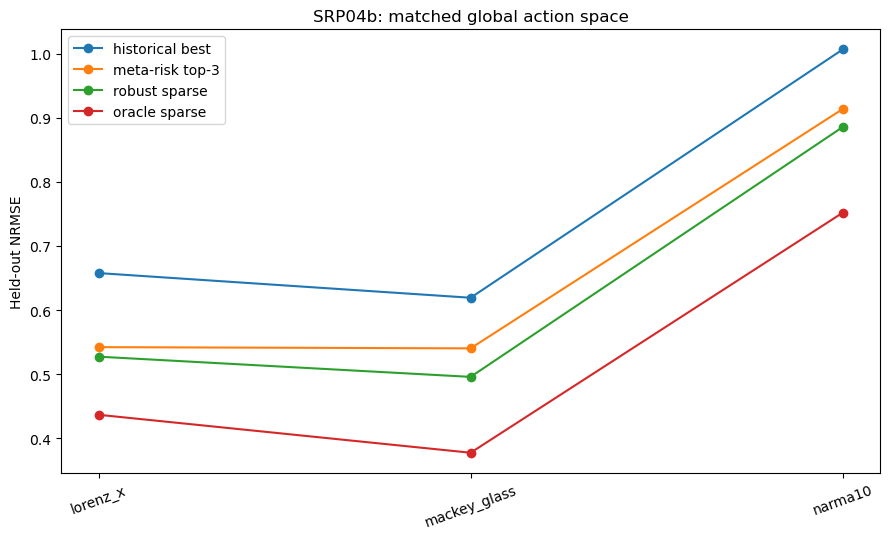

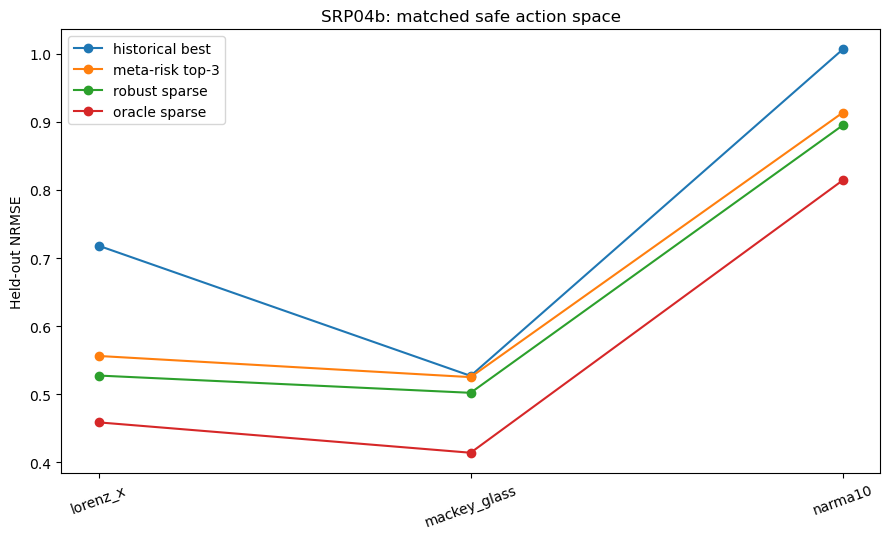

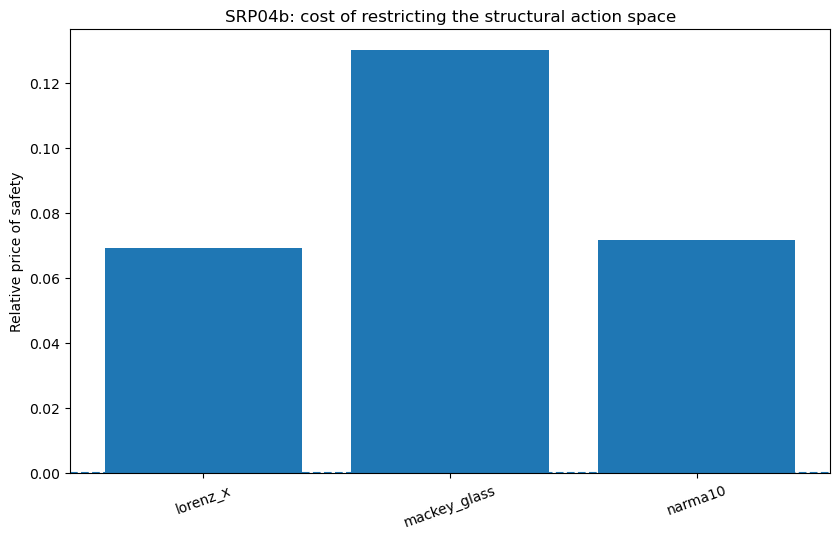

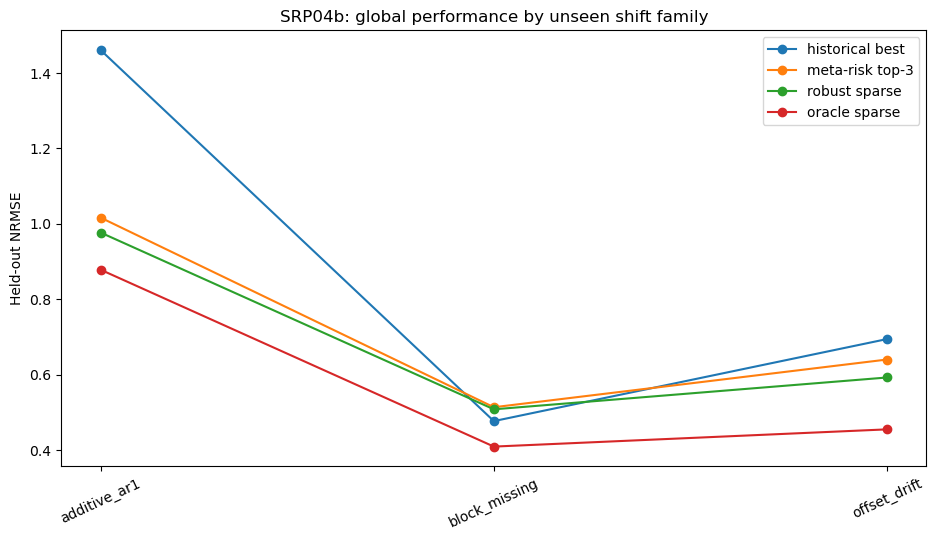

In [16]:

# ============================================================
# Figures
# ============================================================
for domain in ["global", "safe"]:
    table = task_domain_summary[
        task_domain_summary["domain"] == domain
    ].copy()
    x = np.arange(len(table))

    plt.figure(figsize=(9, 5.5))
    plt.plot(
        x,
        table["historical_nrmse"],
        marker="o",
        label="historical best",
    )
    plt.plot(
        x,
        table["meta_top3_nrmse"],
        marker="o",
        label="meta-risk top-3",
    )
    plt.plot(
        x,
        table["robust_sparse_nrmse"],
        marker="o",
        label="robust sparse",
    )
    plt.plot(
        x,
        table["oracle_sparse_nrmse"],
        marker="o",
        label="oracle sparse",
    )
    plt.xticks(
        x,
        table["task"],
        rotation=20,
    )
    plt.ylabel("Held-out NRMSE")
    plt.title(
        f"SRP04b: matched {domain} action space"
    )
    plt.legend()
    plt.tight_layout()
    plt.savefig(
        OUTDIR
        / f"srp04b_{domain}_cross_task_nrmse.png",
        dpi=220,
        bbox_inches="tight",
    )
    plt.show()

plt.figure(figsize=(8.5, 5.5))
x = np.arange(len(safety_summary))
plt.bar(
    x,
    safety_summary[
        "relative_price_of_safety"
    ],
)
plt.axhline(0.0, linestyle="--")
plt.xticks(
    x,
    safety_summary["task"],
    rotation=20,
)
plt.ylabel("Relative price of safety")
plt.title(
    "SRP04b: cost of restricting the structural action space"
)
plt.tight_layout()
plt.savefig(
    OUTDIR / "srp04b_price_of_safety.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()

plt.figure(figsize=(9.5, 5.5))
global_family = family_domain_summary[
    family_domain_summary["domain"] == "global"
]
x = np.arange(len(global_family))
plt.plot(
    x,
    global_family["historical_nrmse"],
    marker="o",
    label="historical best",
)
plt.plot(
    x,
    global_family["meta_top3_nrmse"],
    marker="o",
    label="meta-risk top-3",
)
plt.plot(
    x,
    global_family["robust_sparse_nrmse"],
    marker="o",
    label="robust sparse",
)
plt.plot(
    x,
    global_family["oracle_sparse_nrmse"],
    marker="o",
    label="oracle sparse",
)
plt.xticks(
    x,
    global_family["family"],
    rotation=25,
)
plt.ylabel("Held-out NRMSE")
plt.title(
    "SRP04b: global performance by unseen shift family"
)
plt.legend()
plt.tight_layout()
plt.savefig(
    OUTDIR / "srp04b_global_family_nrmse.png",
    dpi=220,
    bbox_inches="tight",
)
plt.show()


In [17]:

# ============================================================
# Final predeclared publication decision
# ============================================================
def domain_metrics(domain: str):
    task_table = task_domain_summary[
        task_domain_summary["domain"] == domain
    ].copy()
    family_table = family_domain_summary[
        family_domain_summary["domain"] == domain
    ].copy()

    opportunity_fraction = float(
        np.mean(
            task_table["oracle_relative_gain"]
            >= MIN_ORACLE_RELATIVE_GAIN
        )
    )
    robust_fraction = float(
        np.mean(
            task_table["robust_relative_gain"]
            >= MIN_ROBUST_RELATIVE_GAIN
        )
    )
    adaptive_fraction = float(
        np.mean(
            (
                task_table["meta_relative_gain"] > 0.0
            )
            & (
                task_table["meta_capture_fraction"]
                >= MIN_CAPTURE_FRACTION
            )
        )
    )

    mean_historical = float(
        family_table["historical_nrmse"].mean()
    )
    robust_negative_transfer = max(
        0.0,
        -float(family_table["robust_gain"].min())
        / (mean_historical + 1e-12),
    )
    meta_negative_transfer = max(
        0.0,
        -float(family_table["meta_gain"].min())
        / (mean_historical + 1e-12),
    )

    robust_win_fraction = float(
        np.mean(
            task_table["robust_harm_fraction"]
            < 0.50
        )
    )
    adaptive_win_fraction = float(
        np.mean(
            task_table["meta_harm_fraction"]
            < 0.50
        )
    )

    mean_meta = float(
        task_table["meta_top3_nrmse"].mean()
    )
    mean_robust = float(
        task_table["robust_sparse_nrmse"].mean()
    )

    return {
        "opportunity_fraction": opportunity_fraction,
        "robust_fraction": robust_fraction,
        "adaptive_fraction": adaptive_fraction,
        "robust_negative_transfer": robust_negative_transfer,
        "meta_negative_transfer": meta_negative_transfer,
        "robust_win_fraction": robust_win_fraction,
        "adaptive_win_fraction": adaptive_win_fraction,
        "adaptive_competitive": bool(
            mean_meta <= 1.01 * mean_robust
        ),
        "oracle_valid": bool(
            task_table["oracle_valid"].all()
        ),
    }


global_metrics = domain_metrics("global")
safe_metrics = domain_metrics("safe")

price_ok_fraction = float(
    np.mean(
        safety_summary[
            "relative_price_of_safety"
        ] <= MAX_PRICE_OF_SAFETY_RELATIVE
    )
)

global_adaptive_go = bool(
    global_metrics["opportunity_fraction"]
    >= MIN_TASK_FRACTION
    and global_metrics["adaptive_fraction"]
    >= MIN_TASK_FRACTION
    and global_metrics["meta_negative_transfer"]
    <= MAX_NEGATIVE_TRANSFER
    and global_metrics["adaptive_win_fraction"]
    >= MIN_TASK_FRACTION
    and global_metrics["adaptive_competitive"]
)

safe_adaptive_go = bool(
    safe_metrics["opportunity_fraction"]
    >= MIN_TASK_FRACTION
    and safe_metrics["adaptive_fraction"]
    >= MIN_TASK_FRACTION
    and safe_metrics["meta_negative_transfer"]
    <= MAX_NEGATIVE_TRANSFER
    and safe_metrics["adaptive_win_fraction"]
    >= MIN_TASK_FRACTION
    and safe_metrics["adaptive_competitive"]
)

global_aggregation_go = bool(
    global_metrics["opportunity_fraction"]
    >= MIN_TASK_FRACTION
    and global_metrics["robust_fraction"]
    >= MIN_TASK_FRACTION
    and global_metrics["robust_negative_transfer"]
    <= MAX_NEGATIVE_TRANSFER
    and global_metrics["robust_win_fraction"]
    >= MIN_TASK_FRACTION
)

safe_aggregation_go = bool(
    safe_metrics["opportunity_fraction"]
    >= MIN_TASK_FRACTION
    and safe_metrics["robust_fraction"]
    >= MIN_TASK_FRACTION
    and safe_metrics["robust_negative_transfer"]
    <= MAX_NEGATIVE_TRANSFER
    and safe_metrics["robust_win_fraction"]
    >= MIN_TASK_FRACTION
)

gates = {
    "G0_multitask_multiseed_completed": bool(
        len(task_seed_domain_summary)
        == (
            len(TASKS)
            * len(RESERVOIR_SEEDS)
            * 2
        )
    ),
    "G1_global_oracle_valid": bool(
        global_metrics["oracle_valid"]
        and window_table.loc[
            window_table["domain"] == "global",
            "oracle_valid",
        ].all()
    ),
    "G2_safe_oracle_valid": bool(
        safe_metrics["oracle_valid"]
        and window_table.loc[
            window_table["domain"] == "safe",
            "oracle_valid",
        ].all()
    ),
    "G3_global_opportunity_material": bool(
        global_metrics["opportunity_fraction"]
        >= MIN_TASK_FRACTION
    ),
    "G4_safe_opportunity_material": bool(
        safe_metrics["opportunity_fraction"]
        >= MIN_TASK_FRACTION
    ),
    "G5_price_of_safety_acceptable": bool(
        price_ok_fraction
        >= MIN_TASK_FRACTION
    ),
    "G6_global_adaptive_method": global_adaptive_go,
    "G7_safe_adaptive_method": safe_adaptive_go,
    "G8_global_robust_aggregation": global_aggregation_go,
    "G9_safe_robust_aggregation": safe_aggregation_go,
}

valid_protocol = bool(
    gates["G0_multitask_multiseed_completed"]
    and gates["G1_global_oracle_valid"]
    and gates["G2_safe_oracle_valid"]
)

if (
    valid_protocol
    and (
        gates["G6_global_adaptive_method"]
        or gates["G7_safe_adaptive_method"]
    )
):
    decision_label = "GO_ADAPTIVE_METHOD"
    interpretation = (
        "Proceed toward a journal method paper. In at least one matched "
        "action space, label-free structural risk estimation captures a "
        "material fraction of target-specific retuning value without "
        "material negative transfer and remains competitive with robust "
        "aggregation."
    )
elif (
    valid_protocol
    and gates["G3_global_opportunity_material"]
    and (
        gates["G8_global_robust_aggregation"]
        or gates["G9_safe_robust_aggregation"]
    )
):
    decision_label = "GO_LIMITS_AND_AGGREGATION"
    interpretation = (
        "Proceed toward a journal paper on identifiability limits and safe "
        "structural aggregation. Global target-specific retuning has material "
        "oracle value, but robust aggregation is more reliable than direct "
        "unlabeled selection."
    )
else:
    decision_label = "NO_GO"
    interpretation = (
        "Do not create a separate journal paper from this line. The corrected "
        "multi-task evidence does not show sufficiently broad target-specific "
        "opportunity together with a reliable adaptive or aggregation policy. "
        "Retain only the relevant robustness and limitation results in the "
        "Temperature-Calibrated Reservoirs manuscript."
    )

decision_df = pd.DataFrame({
    "gate": list(gates.keys()),
    "passed": list(gates.values()),
})
display(decision_df)

print("GLOBAL METRICS")
print(global_metrics)
print("\\nSAFE METRICS")
print(safe_metrics)
print("\\nprice_ok_fraction:", price_ok_fraction)
print("\\nFINAL DECISION:", decision_label)
print(interpretation)

decision_df.to_csv(
    OUTDIR / "srp04b_decision_gates.csv",
    index=False,
)
(OUTDIR / "srp04b_decision.txt").write_text(
    "\\n".join([
        "SRP04b final corrected journal feasibility decision",
        "===================================================",
        f"decision={decision_label}",
        interpretation,
        "",
        f"global_metrics={global_metrics}",
        f"safe_metrics={safe_metrics}",
        f"price_ok_fraction={price_ok_fraction:.10f}",
        *[
            f"{key}={value}"
            for key, value in gates.items()
        ],
    ]),
    encoding="utf-8",
)


,gate,passed
0,G0_multitask_multiseed_completed,True
1,G1_global_oracle_valid,True
2,G2_safe_oracle_valid,True
3,G3_global_opportunity_material,True
4,G4_safe_opportunity_material,True
5,G5_price_of_safety_acceptable,False
6,G6_global_adaptive_method,False
7,G7_safe_adaptive_method,False
8,G8_global_robust_aggregation,False
9,G9_safe_robust_aggregation,False


GLOBAL METRICS
{'opportunity_fraction': 1.0, 'robust_fraction': 1.0, 'adaptive_fraction': 0.0, 'robust_negative_transfer': 0.03562031019412352, 'meta_negative_transfer': 0.041900157310043255, 'robust_win_fraction': 1.0, 'adaptive_win_fraction': 0.6666666666666666, 'adaptive_competitive': False, 'oracle_valid': True}
\nSAFE METRICS
{'opportunity_fraction': 1.0, 'robust_fraction': 1.0, 'adaptive_fraction': 0.0, 'robust_negative_transfer': 0.033347385369409614, 'meta_negative_transfer': 0.04969867655353327, 'robust_win_fraction': 1.0, 'adaptive_win_fraction': 0.6666666666666666, 'adaptive_competitive': False, 'oracle_valid': True}
\nprice_ok_fraction: 0.0
\nFINAL DECISION: NO_GO
Do not create a separate journal paper from this line. The corrected multi-task evidence does not show sufficiently broad target-specific opportunity together with a reliable adaptive or aggregation policy. Retain only the relevant robustness and limitation results in the Temperature-Calibrated Reservoirs manuscri

1448


## Interpretation rules

### Global opportunity is weak

There is no separate paper, regardless of whether a policy appears to improve
inside a restricted region. The structural optimum does not move enough across
tasks to justify the research problem.

### Global opportunity is strong, adaptation fails, aggregation succeeds

This is the intended `GO_LIMITS_AND_AGGREGATION` result. The contribution is
the empirically demonstrated gap between oracle retuning value and label-free
identifiability, together with a safer aggregation response.

### Adaptation succeeds only inside the safe region

A method paper remains possible, but the claim must explicitly condition on a
historically certified structural action space.

### Price of safety is large

The safe region may still improve reliability, but it excludes substantial
target-specific opportunity. This cost must be reported rather than hidden
inside adaptation regret.

### `NO_GO`

This decision is final for the separate journal line. Additional bespoke
features should not be added. The useful findings should be folded into the
main reservoir manuscript as limitations, robustness evidence or future work.
